In [21]:
import os
import numpy as np
from scipy.signal import welch, butter, sosfiltfilt, freqs
import matplotlib.pyplot as plt
#from scipy.io.wavfile import write
#from scipy.signal import periodogram, spectrogram, oaconvolve
from asammdf import MDF

import librosa

ldf is not supported
xls is not supported
xlsx is not supported


In [23]:
import sys

sys.path.append("../configs/")

import warnings
warnings.filterwarnings("ignore")

import scipy.signal as sg
import scipy.signal as sn

import numpy as np
import emd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

import pywt

In [25]:
import pandas as pd

<h1>On fusionne les csv créés à partir des fichiers tdms</h1>

In [27]:
import glob

files = [
    f"/Volumes/Seagate Drive/pdi/nouvelle_tournee/24091902si11/File_by_file/results_00{i}.csv"
    for i in range(2, 10)  # Génère results_002.csv à results_011.csv
]

# fusionner les fichiers
df_combined = pd.concat([pd.read_csv(file) for file in files], ignore_index=True)

print(df_combined.head())

   /'Acquisitions'/'331_X_HB'  /'Acquisitions'/'331_Z_GD'  \
0                   -0.081562                    0.001001   
1                   -0.083043                    0.001494   
2                   -0.091759                    0.001165   
3                   -0.083700                    0.002317   
4                   -0.086168                    0.003139   

   /'Acquisitions'/'331_Y_AvAr'  /'Acquisitions'/'332_X_HB'  \
0                     -0.003275                    0.089649   
1                     -0.003440                    0.077808   
2                     -0.009854                    0.076821   
3                     -0.005907                    0.082906   
4                     -0.004591                    0.080110   

   /'Acquisitions'/'332_Z_GD'  /'Acquisitions'/'332_Y_AvAr'  \
0                    0.004784                      0.002646   
1                    0.001165                      0.004784   
2                   -0.004262                      0.005113   
3 

In [29]:
df = df_combined

In [105]:
df.columns

Index(['/'Acquisitions'/'331_X_HB'', '/'Acquisitions'/'331_Z_GD'',
       '/'Acquisitions'/'331_Y_AvAr'', '/'Acquisitions'/'332_X_HB'',
       '/'Acquisitions'/'332_Z_GD'', '/'Acquisitions'/'332_Y_AvAr'',
       '/'Acquisitions'/'Audio_1'', '/'Acquisitions'/'Audio_2'',
       '/'Acquisitions'/'ODO_Counter''],
      dtype='object')

In [107]:
df.head()

,/'Acquisitions'/'331_X_HB',/'Acquisitions'/'331_Z_GD',/'Acquisitions'/'331_Y_AvAr',/'Acquisitions'/'332_X_HB',/'Acquisitions'/'332_Z_GD',/'Acquisitions'/'332_Y_AvAr',/'Acquisitions'/'Audio_1',/'Acquisitions'/'Audio_2',/'Acquisitions'/'ODO_Counter'
0,-0.081562,0.001001,-0.003275,0.089649,0.004784,0.002646,0.018435,0.018106,30350845.0
1,-0.083043,0.001494,-0.003440,0.077808,0.001165,0.004784,0.020244,0.018928,30350845.0
2,-0.091759,0.001165,-0.009854,0.076821,-0.004262,0.005113,0.020573,0.020408,30350845.0
3,-0.083700,0.002317,-0.005907,0.082906,-0.008209,0.005606,0.018270,0.018106,30350845.0
4,-0.086168,0.003139,-0.004591,0.080110,-0.005907,0.001001,0.014323,0.014158,30350845.0


In [109]:
df["/'Acquisitions'/'ODO_Counter'"][0]

30350845.0

In [31]:
df.shape

(4000000, 9)

In [115]:
df["/'Acquisitions'/'ODO_Counter'"][3999999]

37501648.0

On créé la colonne timestamp artificiellement

In [33]:
# Générer une colonne 'timestamp' en considérant une fréquence de 10kHz
df['timestamp'] = np.arange(0, len(df) * 0.0001, 0.0001)

print(df[["/'Acquisitions'/'ODO_Counter'", 'timestamp']].head())


   /'Acquisitions'/'ODO_Counter'  timestamp
0                     30350845.0     0.0000
1                     30350845.0     0.0001
2                     30350845.0     0.0002
3                     30350845.0     0.0003
4                     30350845.0     0.0004


<h1>On trace la courbe temporelle</h1>

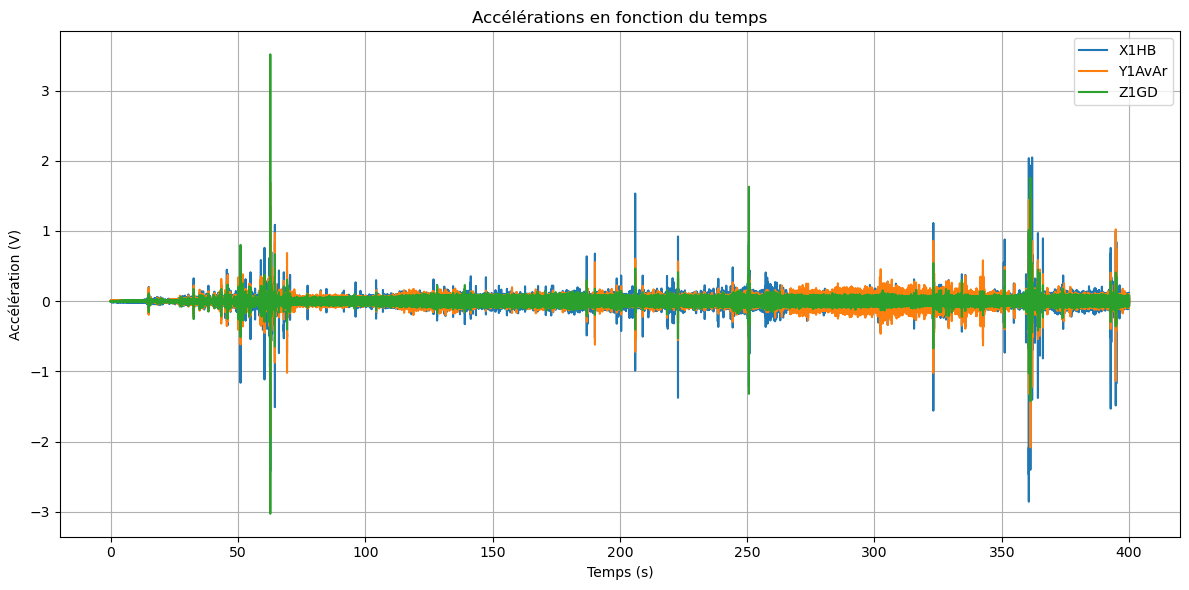

In [35]:
X1AvAr = df["/'Acquisitions'/'331_X_HB'"].to_numpy() - np.mean(df["/'Acquisitions'/'331_X_HB'"])
Y1GD = df["/'Acquisitions'/'331_Y_AvAr'"].to_numpy() - np.mean(df["/'Acquisitions'/'331_Y_AvAr'"])
Z1HB = df["/'Acquisitions'/'331_Z_GD'"].to_numpy() - np.mean(df["/'Acquisitions'/'331_Z_GD'"])
t = df['timestamp']
# Tracé des courbes
plt.figure(figsize=(12, 6))

plt.plot(t, X1AvAr, label='X1HB')
plt.plot(t, Y1GD, label='Y1AvAr')
plt.plot(t, Z1HB, label='Z1GD')

# Personnalisation des graphes
plt.xlabel('Temps (s)')
plt.ylabel('Accélération (V)')
plt.title('Accélérations en fonction du temps')
plt.legend()  # Affiche la légende
plt.grid(True)  # Ajoute une grille
plt.tight_layout()

plt.show()

<h1>On définit les fonctions de traitement de signal</h1>

In [37]:
def comp_fft(df1, sensor="Cab1_BE_AV_G", sampling_sensor="time", plot=False):
    """
        Calcule la FFT d'un signal 1D.

        Parameters
        ----------
        df1 : DataFrame
            DataFrame contenant la colonne à analyser ainsi que la colonne de l'échantillonnage.
        sensor : str, optional
            Colonne à analyser, par défaut "Cab1_BE_AV_G".
        sampling_sensor : str, optional
            Type d'échantillonnage à considérer, par défaut "time".
        plot : bool, optional
            Afficher ou non le résultat, par défaut False.

        Returns
        -------
        xf : 1D array_like
            Liste des fréquences.
        fft_values : 1D array_like
            Liste des valeurs FFT associées à chaque fréquence de xf.
    """


    N = len(df1)
    if pd.api.types.is_datetime64_any_dtype(df1[sampling_sensor]):
      T = df1[sampling_sensor].diff().dt.total_seconds().mean()
    else:
      T = df1[sampling_sensor].diff().mean()  # Pour les cas où c'est déjà un float
    y = df1[sensor].values

    yf = fft(y)
    yf[0] /= 2
    xf = fftfreq(N, T)[: N // 2]

    fft_values = 2.0 / N * np.abs(yf[0 : N // 2])
    if plot:
        # Plot the PSD
        fig , axs = plt.subplots(1,1,sharex=True)
        axs.plot(xf, fft_values, color="red", alpha=0.9)
        axs.set_title('Fast Fourrier Transform (FFT) \n '+sensor)

        if sampling_sensor == "time":
            axs.set_xlabel('Frequency [$Hz$]')
        else :
            axs.set_xlabel('Frequency [$m^{-1}$]')

        axs.set_ylabel('FFT values')
        axs.legend()
        fig.tight_layout()


    return xf, fft_values

In [39]:
def comp_psd(df1, sensor, nperseg=512, sampling_sensor="time", plot=False):
    """
        Calcule la PSD d'un signal 1D.

        Parameters
        ----------
        df1 : DataFrame
            DataFrame contenant la colonne à analyser ainsi que la colonne de l'échantillonnage.
        sensor : str, optional
            Colonne à analyser, par défaut "Cab1_BE_AV_G".
        nperseg : int, optional
            Longueur de chaque segment, par défaut 512.
        sampling_sensor : str, optional
            Type d'échantillonnage à considérer, par défaut "time".
        plot : bool, optional
            Afficher ou non le résultat, par défaut False.

        Returns
        -------
        xf : 1D array_like
            Liste des fréquences.
        fft_values : 1D array_like
            Liste des valeurs PSD associées à chaque fréquence de xf.
    """
    df = df1.copy()
    #fs = int(1/np.abs(df[sampling_sensor].diff().mean()))
    if pd.api.types.is_datetime64_any_dtype(df1[sampling_sensor]):
      fs = int(1/np.abs(df[sampling_sensor].diff().dt.total_seconds().mean()))
    else:
      fs = int(1/np.abs(df[sampling_sensor].diff().mean()))  # Pour les cas où c'est déjà un float
    # Compute the PSD using the Welch method
    frequencies, psd = sn.welch(df[sensor].values, fs, nperseg=nperseg, average="mean")

    if plot :
        # Plot the PSD
        fig , axs = plt.subplots(1,1,sharex=True)
        # axs.semilogx(frequencies, psd)
        axs.plot(frequencies, psd, color="red")
        axs.set_title('Power Spectral Density (PSD) \n '+sensor)
        if sampling_sensor == "time":
            axs.set_xlabel('Frequency [$Hz$]')
        else :
            axs.set_xlabel('Frequency [$m^{-1}$]')

        axs.set_ylabel('Power/Frequency')
        fig.tight_layout()

    return frequencies, psd

In [41]:
def high_pass_filter(df, sensors, highcut_freq, order=4, sampling_sensor="time", plot=False):
    """
        Filtre passe-bas de Butterworth

        Parameters
        ----------
        df : DataFrame
            DataFrame contenant les colonnes à filtrer ainsi que la colonne de l'échantillonnage.
        sensors : list
            Liste des colonnes à filtrer.
        highcut_freq : float
            Fréquence de coupure.
        order : int, optional
            Ordre du filtre. Par défaut, 4.
        sampling_sensor : str, optional
            Choix entre un filtrage spatial ou temporel. Par défaut, 'time'.
        plot : bool, optional
            Afficher ou non le resultat , by default False

        Returns
        -------
        DataFrame
            DataFrame contenant les colonnes filtrées et renommées avec '_filt' ajouté à la fin de chaque nom de colonne.
    """
    df_filt = df.copy()
    #fs = 1 / df[sampling_sensor].diff().abs().median()
    if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
      fs = int(1/np.abs(df[sampling_sensor].diff().dt.total_seconds().abs().median()))
    else:
      fs = 1 / df[sampling_sensor].diff().abs().median()  # Pour les cas où c'est déjà un float
    nyq = 0.5 * fs
    high = highcut_freq / nyq
    b, a = sg.butter(order, high, btype="high")
    padlen = max(3 * max(len(a), len(b)), int(len(df)*0.01))
    if type(sensors) == str:
        df_filt[sensors] = sg.filtfilt(b, a, df_filt[sensors], padtype="even", padlen=padlen, method="pad")
    else:
        df_filt[sensors] = df_filt[sensors].apply(lambda x: sg.filtfilt(b, a, x, padtype="even", padlen=padlen, method="pad"))

    if plot :
        # domaine frequentiel avant et apres filtrage.
        if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
          Fe = int(1 / (df[sampling_sensor].diff().dt.total_seconds().mean()))
        else:
          Fe = int(1 / (df[sampling_sensor].diff().mean()))  # Pour les cas où c'est déjà un float
        sensor = sensors[0]
        xf1, fft_values1 = comp_fft(df, sensor, plot=False, sampling_sensor=sampling_sensor)
        xf2, fft_values2 = comp_fft(df_filt, sensor, plot=False, sampling_sensor=sampling_sensor)

        fig, axs = plt.subplots(2,1)

        axs[0].plot(df[sampling_sensor], df[sensor], color="red", alpha=0.6, label="Avant filtrage")
        axs[0].plot(df_filt[sampling_sensor], df_filt[sensor], color="blue", alpha=0.6, label="Après filtrage")
        axs[0].set_ylabel(sensor)
        axs[0].set_xlabel(sampling_sensor)
        axs[0].legend()

        axs[1].plot(
            xf1,
            fft_values1,
            color="red",
            alpha=0.3,
            label="Avant filtrage",
        )
        axs[1].plot(
            xf2,
            fft_values2,
            color="blue",
            alpha=0.3,
            label="Apres filtrage",
        )
        axs[1].set_ylabel("FFT values")

        if sampling_sensor == "time":
            unit = "$[Hz]$"
            axs[0].set_title("Filtrage de [ 0 - " + str(Fe//2) + " ] $Hz$ à [ 0 - " + str(highcut_freq) + " ] $Hz$ \n"+sensor)
        else :
            unit = "$[m^{-1}]$"
            axs[0].set_title("Filtrage de [ 0 - " + str(Fe//2) + " ] $m^{-1}$ à [ 0 - " + str(highcut_freq) + " ] $m^{-1}$ \n"+sensor)

        axs[1].set_xlabel('Frequency '+unit)
        axs[1].legend()
        fig.tight_layout()

    return df_filt

In [43]:
def low_pass_filter(df, sensors, lowcut_freq, order=4, sampling_sensor="time", plot=False):
    """
        Filtre passe-bas de Butterworth

        Parameters
        ----------
        df : DataFrame
            DataFrame contenant les colonnes à filtrer ainsi que la colonne de l'échantillonnage.
        sensors : list
            Liste des colonnes à filtrer.
        lowcut_freq : float
            Fréquence de coupure.
        order : int, optional
            Ordre du filtre. Par défaut, 4.
        sampling_sensor : str, optional
            Choix entre un filtrage spatial ou temporel. Par défaut, 'time'.
        plot : bool, optional
            Afficher ou non le resultat , by default False

        Returns
        -------
        DataFrame
            DataFrame contenant les colonnes filtrées et renommées avec '_filt' ajouté à la fin de chaque nom de colonne.
    """
    df_filt = df.copy()
    if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
      fs = int(1/np.abs(df[sampling_sensor].diff().dt.total_seconds().abs().median()))
    else:
      fs = 1 / df[sampling_sensor].diff().abs().median()  # Pour les cas où c'est déjà un float
    nyq = 0.5 * fs
    low = lowcut_freq / nyq
    b, a = sg.butter(order, low, btype="low")
    padlen = max(3 * max(len(a), len(b)), int(len(df)*0.01))
    if type(sensors) == str:
        df_filt[sensors] = sg.filtfilt(b, a, df_filt[sensors], padtype="even", padlen=padlen, method="pad")
    else:
        df_filt[sensors] = df_filt[sensors].apply(lambda x: sg.filtfilt(b, a, x, padtype="even", padlen=padlen, method="pad"))

    if plot :
        # domaine frequentiel avant et apres filtrage.
        if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
          Fe = int(1 / (df[sampling_sensor].diff().dt.total_seconds().mean()))
        else:
          Fe = int(1 / (df[sampling_sensor].diff().mean()))  # Pour les cas où c'est déjà un float
        sensor = sensors[0]
        xf1, fft_values1 = comp_fft(df, sensor, plot=False, sampling_sensor=sampling_sensor)
        xf2, fft_values2 = comp_fft(df_filt, sensor, plot=False, sampling_sensor=sampling_sensor)

        fig, axs = plt.subplots(2,1)

        axs[0].plot(df[sampling_sensor], df[sensor], color="red", alpha=0.6, label="Avant filtrage")
        axs[0].plot(df_filt[sampling_sensor], df_filt[sensor], color="blue", alpha=0.6, label="Après filtrage")
        axs[0].set_ylabel(sensor)
        axs[0].set_xlabel(sampling_sensor)
        axs[0].legend()

        axs[1].plot(
            xf1,
            fft_values1,
            color="red",
            alpha=0.3,
            label="Avant filtrage",
        )
        axs[1].plot(
            xf2,
            fft_values2,
            color="blue",
            alpha=0.3,
            label="Apres filtrage",
        )
        axs[1].set_ylabel("FFT values")

        if sampling_sensor == "time":
            unit = "$[Hz]$"
            axs[0].set_title("Filtrage de [ 0 - " + str(Fe//2) + " ] $Hz$ à [ 0 - " + str(lowcut_freq) + " ] $Hz$ \n"+sensor)
        else :
            unit = "$[m^{-1}]$"
            axs[0].set_title("Filtrage de [ 0 - " + str(Fe//2) + " ] $m^{-1}$ à [ 0 - " + str(lowcut_freq) + " ] $m^{-1}$ \n"+sensor)

        axs[1].set_xlabel('Frequency '+unit)
        axs[1].legend()
        fig.tight_layout()

    return df_filt

In [45]:
def band_pass_filter(df, sensors, fmin, fmax, order=2, sampling_sensor="time", plot=False):
    """
        Filtre passe-haut de Butterworth

        Parameters
        ----------
        df : DataFrame
            DataFrame contenant les colonnes à filtrer ainsi que la colonne de l'échantillonnage.
        sensors : list
            Liste des colonnes à filtrer.
        fmin : float
            Fréquence de coupure minimale.
        fmax : float
            Fréquence de coupure maximale.
        order : int, optional
            Ordre du filtre. Par défaut, 4.
        sampling_sensor : str, optional
            Choix entre un filtrage spatial ou temporel. Par défaut, 'time'.

        Returns
        -------
        DataFrame
            DataFrame contenant les colonnes filtrées et renommées avec '_filt' ajouté à la fin de chaque nom de colonne.
    """
    df_filt = df.copy()

    if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
      dt =  df[sampling_sensor].diff().dt.total_seconds().abs().mean()
    else:
      dt =  df[sampling_sensor].diff().abs().mean()  # Pour les cas où c'est déjà un float

    b, a = sg.butter(order, [2 * fmin * dt, 2 * fmax * dt], btype="bandpass")
    padlen = max(3 * max(len(a), len(b)), int(len(df)*0.01))
    if type(sensors) == str:
        df_filt[sensors] = sg.filtfilt(b, a, df_filt[sensors], padtype="even", padlen=padlen, method="pad")
    else:
        df_filt[sensors] = df_filt[sensors].apply(lambda x: sg.filtfilt(b, a, x, padtype="even", padlen=padlen, method="pad"))

    if plot:
        # domaine frequentiel avant et apres filtrage.
        if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
          Fe = int(1 / (df[sampling_sensor].diff().dt.total_seconds().mean()))
        else:
          Fe = int(1 / (df[sampling_sensor].diff().mean()))  # Pour les cas où c'est déjà un float
        sensor = sensors[0]
        xf1, fft_values1 = comp_fft(df, sensor, plot=False, sampling_sensor=sampling_sensor)
        xf2, fft_values2 = comp_fft(df_filt, sensor, plot=False, sampling_sensor=sampling_sensor)

        fig, axs = plt.subplots(2,1)

        axs[0].plot(df[sampling_sensor], df[sensor], color="red", alpha=0.6, label="Avant filtrage")
        axs[0].plot(df_filt[sampling_sensor], df_filt[sensor], color="blue", alpha=0.6, label="Après filtrage")
        axs[0].set_ylabel(sensor)
        axs[0].set_xlabel(sampling_sensor)
        axs[0].legend()

        axs[1].plot(
            xf1,
            fft_values1,
            color="red",
            alpha=0.3,
            label="Avant filtrage",
        )
        axs[1].plot(
            xf2,
            fft_values2,
            color="blue",
            alpha=0.3,
            label="Apres filtrage",
        )
        axs[1].set_ylabel("FFT values")

        if sampling_sensor == "time":
            unit = "$[Hz]$"
            axs[0].set_title("Filtrage de [ 0 - " + str(Fe//2) + " ] $Hz$ à [ " + str(fmin) + " - " + str(fmax) + " ] $Hz$ \n"+sensor)
        else :
            unit = "$[m^{-1}]$"
            axs[0].set_title("Filtrage de [ 0 - " + str(Fe//2) + " ] $m^{-1}$ à [ " + str(fmin) + " - " + str(fmax) + " ] $m^{-1}$ \n"+sensor)

        axs[1].set_xlabel('Frequency '+unit)
        axs[1].legend()
        fig.tight_layout()


    return df_filt

In [47]:
def band_stop_filter(df, sensors, fmin, fmax, order=2, sampling_sensor="time", plot=False):
    """
        Filtre passe-haut de Butterworth

        Parameters
        ----------
        df : DataFrame
            DataFrame contenant les colonnes à filtrer ainsi que la colonne de l'échantillonnage.
        sensors : list
            Liste des colonnes à filtrer.
        fmin : float
            Fréquence de coupure minimale.
        fmax : float
            Fréquence de coupure maximale.
        order : int, optional
            Ordre du filtre. Par défaut, 4.
        sampling_sensor : str, optional
            Choix entre un filtrage spatial ou temporel. Par défaut, 'time'.

        Returns
        -------
        DataFrame
            DataFrame contenant les colonnes filtrées.
    """
    df_filt = df.copy()
    if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
      dt =  df[sampling_sensor].diff().dt.total_seconds().abs().mean()
    else:
      dt =  df[sampling_sensor].diff().abs().mean()  # Pour les cas où c'est déjà un float

    b, a = sg.butter(order, [2 * fmin * dt, 2 * fmax * dt], btype="bandstop")
    padlen = max(3 * max(len(a), len(b)), int(len(df)*0.01))
    if type(sensors) == str:
        df_filt[sensors] = sg.filtfilt(b, a, df_filt[sensors], padtype="even", padlen=padlen, method="pad")
    else:
        df_filt[sensors] = df_filt[sensors].apply(lambda x: sg.filtfilt(b, a, x, padtype="even", padlen=padlen, method="pad"))

    if plot:
        # domaine frequentiel avant et apres filtrage.
        if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
          Fe = int(1 / (df[sampling_sensor].diff().dt.total_seconds().mean()))
        else:
          Fe = int(1 / (df[sampling_sensor].diff().mean()))  # Pour les cas où c'est déjà un float
        sensor = sensors[0]
        xf1, fft_values1 = comp_fft(df, sensor, plot=False, sampling_sensor=sampling_sensor)
        xf2, fft_values2 = comp_fft(df_filt, sensor, plot=False, sampling_sensor=sampling_sensor)

        fig, axs = plt.subplots(2,1, figsize=(45,20),constrained_layout=True)

        axs[0].plot(df[sampling_sensor], df[sensor], color="red", alpha=0.6, label="Avant filtrage")
        axs[0].plot(df_filt[sampling_sensor], df_filt[sensor], color="blue", alpha=0.6, label="Après filtrage")
        axs[0].set_ylabel(sensor)
        axs[0].set_xlabel(sampling_sensor)
        axs[0].legend()

        axs[1].plot(
            xf1,
            fft_values1,
            color="red",
            alpha=0.3,
            label="Avant filtrage",
        )
        axs[1].plot(
            xf2,
            fft_values2,
            color="blue",
            alpha=0.3,
            label="Apres filtrage",
        )
        axs[1].set_ylabel("FFT values")

        if sampling_sensor == "time":
            unit = "$[Hz]$"
            axs[0].set_title("Bande exclu :  [ " + str(fmin) + " - " + str(fmax) + " ] $Hz$ \n"+sensor)
        else :
            unit = "$[m^{-1}]$"
            axs[0].set_title("Bande exclu :  [ " + str(fmin) + " - " + str(fmax) + " ] $m^{-1}$ \n"+sensor)

        axs[1].set_xlabel('Frequency '+unit)
        axs[1].legend()
        fig.tight_layout()


    return df_filt

In [49]:
def sawp( df, sensor="Cab1_BE_AV_G", wavelet="cmor1.5-1.0", fmin=5, fmax=800, sampling_sensor="time", plot=False):
    """
    Calcul la SAWP d'un signal 1D

    Parameters
    ----------
    df : DataFrame
            DataFrame contenant la colonne à analyser ainsi que la colonne de l'échantillonnage.
    sensor : str, optional
        colonne à analyser, by default "Cab1_BE_AV_G"
    wavelet : str, optional
        ondelette mère, by default "cmor1.5-1.0"
    fmin : int, optional
        fréquence minimale à analyser, by default 5
    fmax : int, optional
        fréquence maximale, by default 800
    sampling_sensor : str, optional
        type d'echantillonnage à considerer, by default "time"
    plot : bool, optional
        Afficher ou non le resultat , by default False

    Returns
    -------
    1D array_like
        coefficients de la SAWP
    """
    #df["time_seconds"] = (df[sampling_sensor] - df[sampling_sensor].min()).dt.total_seconds()
    p = np.polyfit(df[sampling_sensor], df[sensor], 1)
    #p = np.polyfit(df["time_seconds"], df[sensor], 1)
    dat_notrend = df[sensor] - np.polyval(p, df[sampling_sensor])

    #dat_notrend = df[sensor] - np.polyval(p, df[sampling_sensor])
    std = dat_notrend.std()  # Standard deviation
    var = std**2  # Variance
    dat_norm = dat_notrend / std  # Normalized dataset

    #if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
    #  dt =  df[sampling_sensor].diff().dt.total_seconds().mean()
    #else:
    #  dt =  df[sampling_sensor].diff().mean()  # Pour les cas où c'est déjà un float
    dt =  df[sampling_sensor].diff().mean()
    print(dt)

    frequencies = np.array(np.linspace(fmin, fmax + 1, 65)) * dt  # normalize
    scales = pywt.frequency2scale(wavelet, frequencies)

    print(scales)

    wave, freqs = pywt.cwt(np.array(dat_norm), scales, wavelet, sampling_period=dt)

    power = (np.abs(wave)) ** 2
    power /= scales[:, None]

    n = df[sensor].size

    c_delta = 1
    scale_avg = (scales * np.ones((n, 1))).transpose()
    scale_avg = power / scale_avg  # As in Torrence and Compo (1998) equation 24
    scale_avg = var / c_delta * scale_avg[:, :].sum(axis=0)

    if plot:
        fig, axs = plt.subplots(2,1, sharex=True)
        axs[0].plot(df[sampling_sensor], df[sensor], "b-", linewidth=1, alpha=0.9)
        axs[1].plot(df[sampling_sensor], scale_avg, "k-", linewidth=1.5, alpha=0.9)
        axs[0].set_title(sensor + " SAWP")
        axs[1].set_xlabel(sampling_sensor)
        axs[0].set_ylabel(sensor)
        axs[1].set_ylabel(f"SAWP {fmin} - {fmax} ")

        fig.tight_layout()

    return scale_avg

In [51]:
def stft(
    df,
    sensor,
    pkd=-1,
    pkf=-1,
    nperseg=512,
    nfft = 512,
    noverlap=int(0.5 * 500),
    window="hann",
    sampling_sensor="time",
    log_plot = False,
    plot=False,
    get_axs = False,
):
    """
        Cette fonction est utilisée pour calculer la transformée de Fourier à court terme (STFT) du signal.

        Parameters
        ----------
        df : DataFrame
            DataFrame contenant la colonne à analyser ainsi que la colonne de l'échantillonnage.
        sensor : str
            colonne à analyser.
        pkd : float, optional
            point de depart du signal à analyser
        pkf : float, optional
            point d'arrivé du signal à analyser
        nperseg : int
            Longueur de chaque segment.
        nfft : int
            Longueur de chaque segment.
        noverlap : int
            Nombre de points de chevauchement entre les segments.
        window : str or tuple or array_like
            Fenêtre désirée à utiliser.
        sampling_sensor : str
            type d'echantillonnage à considerer.
        log_plot : bool, optional
            afficher le log10 du spectogramme
        plot : bool, optional
            Afficher ou non le resultat
        get_axs : bool, optional
            retourner la figure et ses axes

        Returns
        -------
        stft_matr : ndarray
            Résultats du spectre 2D (axe horizontal : temps, axe vertical : fréquence).
        freqs : ndarray
            Axe vertical des fréquences (en Hz).
        time : ndarray
            Axe horizontal du temps (en secondes).

        References
        ----------
        .. [1] Oppenheim, Alan V., Ronald W. Schafer, John R. Buck, “Discrete-Time Signal Processing”,
            Prentice Hall, 1999.
        .. [2] Daniel W. Griffin, Jae S. Lim, “Signal Estimation from Modified Short-Time Fourier Transform”,
            IEEE 1984, 10.1109/TASSP.1984.1164317
    """

    if pkf == -1:
        pkf = df[sampling_sensor].max()
    if pkd == -1:
        pkd = df[sampling_sensor].min()

    #if pd.api.types.is_datetime64_any_dtype(df[sampling_sensor]):
    #  fs = int(1/np.abs(df[sampling_sensor].diff().dt.total_seconds().abs().mean()))
    #else:
    #  fs = 1 / df[sampling_sensor].diff().abs().mean()  # Pour les cas où c'est déjà un float
    fs = 1 / df[sampling_sensor].diff().abs().mean()
    freqs, time, stft_matr = sg.stft(
        df[sensor],
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        nfft = nfft,
        window=window,
        padded=True,
        boundary="zeros"
    )

    if plot:
        # draw the magnitute of the spectrum x_axis : pk, y_axis : frequence
        #df_sampling_seconds = (df[sampling_sensor] - df[sampling_sensor].iloc[0]).dt.total_seconds()
        #df_pk = np.interp(time, df_sampling_seconds, df_sampling_seconds)
        df_pk = np.interp(time, df[sampling_sensor] - df[sampling_sensor].iloc[0], df[sampling_sensor])

        fig, axs = plt.subplots(2,1, sharex=True)
        axs[0].plot(df[sampling_sensor], df[sensor], color="blue", alpha=0.8)
        axs[0].set_ylabel(sensor)

        if log_plot:
            axs[1].contourf(df_pk, freqs, np.log10(np.abs(stft_matr)), 100)
        else :
            axs[1].contourf(df_pk, freqs, np.abs(stft_matr) ** 2, 100)

        axs[1].set_xlabel(sampling_sensor)
        if sampling_sensor == "time":
            axs[1].set_ylabel("Frequence [Hz]")
        else :
            axs[1].set_ylabel("Frequence [$m^{-1}$]")
        axs[0].set_title(sensor + " STFT "+  "\n windows : " + window)
        fig.tight_layout()

        if get_axs:
            return stft_matr, freqs, time, fig, axs

    return stft_matr, freqs, time

In [53]:
def cwt( df, sensor, pkd=-1, pkf=-1, wavelet="cmorl1.5-1",  fmin=5, fmax=800, sampling_sensor="time",  plot=True, get_axs = False, ):
    """
        Cette fonction est utilisée pour calculer la transformée ondelette continue (CWT) du signal.

        Parameters
        ----------
        df : DataFrame
            DataFrame contenant la colonne à analyser ainsi que la colonne de l'échantillonnage.
        sensor : str
            colonne à analyser.
        pkd : float, optional
            point de depart du signal à analyser
        pkf : float, optional
            point d'arrivé du signal à analyser
        wavelet : str, optional
            ondelette mère, by default "cmorl1.5-1"
        fmin : int, optional
            fréquence minimale à analyser, by default 5
        fmax : int, optional
            fréquence maximale, by default 800
        sampling_sensor : str, optional
            Choix entre un filtrage spatial ou temporel. Par défaut, 'time'.
        plot : bool, optional
            Afficher ou non le resultat , by default False

        Returns
        -------
        cwtmatr : ndarray
            Résultats du spectre 2D (axe horizontal : temps, axe vertical : fréquence).
        freqs : ndarray
            Axe vertical des fréquences.

    """
    if pkf == -1:
        pkf = df[sampling_sensor].max()
    if pkd == -1:
        pkd = df[sampling_sensor].min()
    df_filt = df.loc[(df[sampling_sensor] >= pkd) & (df[sampling_sensor] <= pkf)]

    dt =  df_filt[sampling_sensor].diff().abs().mean()  # Pour les cas où c'est déjà un float
    dt = np.round(dt, 6)
    frequencies = np.linspace(fmin, fmax, 65)
    frequencies = np.array(frequencies) * dt # normalise frequencies
    scales = pywt.frequency2scale(wavelet, frequencies)
    cwtmatr, freqs = pywt.cwt(
        df_filt[sensor], scales, wavelet, sampling_period=dt
    )

    if plot:
        # draw the magnitute of the spectrum x_axis : pk, y_axis : frequence
        fig, axs = plt.subplots(2,1, sharex=True)
        axs[1].contourf(df_filt[sampling_sensor], freqs, np.squeeze(np.abs(cwtmatr)**2), 100)
        axs[0].plot(df[sampling_sensor], df[sensor], color="blue", alpha=0.8)
        axs[0].set_title(sensor + " CWT \nWavelet : [" + wavelet + "]")
        axs[0].set_ylabel(sensor)
        axs[1].set_xlabel(sampling_sensor)
        axs[1].grid(False)
        if sampling_sensor == "time":
            axs[1].set_ylabel("Frequence [Hz]")
        else :
            axs[1].set_ylabel("Frequence [$m^{-1}$]")
        fig.tight_layout()

        if get_axs:
            return cwtmatr, freqs, fig, axs

    return cwtmatr, freqs

In [55]:
def get_env_signal(df1, sensor, mode="upper", plot=False, sampling_sensor="time", ymin=10):

    """
        Extrait l'envelloppe inferieure ou superieure d'un signal

        Parameters
        ----------
        df : DataFrame
            DataFrame contenant les colonnes à filtrer ainsi que la colonne de l'échantillonnage.
        sensor : str
            colonnes à analyser.
        mode : str
            envelloppe inferieur (lower) ou superieur (upper), Par défaut upper.
        plot : bool, optional
            Afficher ou non le resultat , by default False

        Returns
        -------
        DataFrame
            DataFrame contenant l'envelloppe du signal.
    """

    df = df1.copy()
    df["env_" + mode + "_" + sensor] = emd.sift.interp_envelope(
        df[sensor].values, mode=mode, interp_method="pchip"
    )
    df = df.loc[df[sensor] == df["env_" + mode + "_" + sensor]]
    df = df.loc[df[sensor].abs()>ymin]
    if plot:
        fig, axs = plt.subplots(1,1,sharex=True)
        axs.plot(df1[sampling_sensor], df1[sensor], alpha=0.3, color="red", label=sensor)
        axs.scatter(df[sampling_sensor], df["env_" + mode + "_" + sensor], alpha=0.8, color="blue", label=mode+" envelope of "+sensor)
        axs.set_xlabel(sampling_sensor)
        axs.set_ylabel(sensor)
        axs.legend()
        fig.tight_layout()

    return df

<h1>FFT des canaux du premier accéléromètre</h1>

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(array([0.0000000e+00, 2.5000000e-03, 5.0000000e-03, ..., 4.9999925e+03,
        4.9999950e+03, 4.9999975e+03]),
 array([3.04467067e-03, 7.92866460e-04, 5.37035118e-04, ...,
        5.00214755e-06, 7.44748485e-06, 1.00254344e-06]))

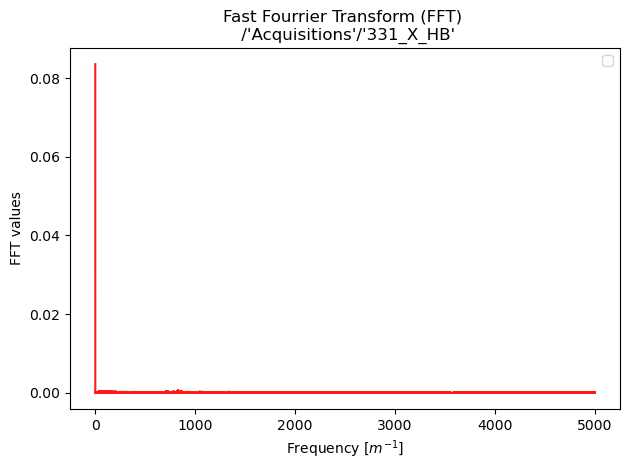

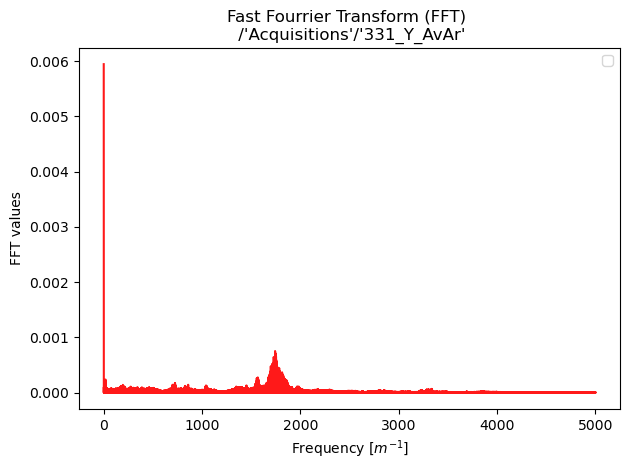

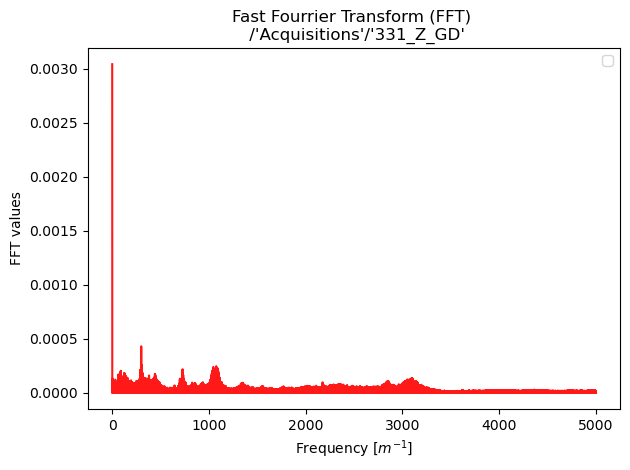

In [121]:
comp_fft(df, sensor="/'Acquisitions'/'331_X_HB'", sampling_sensor="timestamp", plot=True)
comp_fft(df, sensor="/'Acquisitions'/'331_Y_AvAr'", sampling_sensor="timestamp", plot=True)
comp_fft(df, sensor="/'Acquisitions'/'331_Z_GD'", sampling_sensor="timestamp", plot=True)

<h1>PSD des canaux du premier accéléromètre</h1>

(array([   0.     ,   19.53125,   39.0625 ,   58.59375,   78.125  ,
          97.65625,  117.1875 ,  136.71875,  156.25   ,  175.78125,
         195.3125 ,  214.84375,  234.375  ,  253.90625,  273.4375 ,
         292.96875,  312.5    ,  332.03125,  351.5625 ,  371.09375,
         390.625  ,  410.15625,  429.6875 ,  449.21875,  468.75   ,
         488.28125,  507.8125 ,  527.34375,  546.875  ,  566.40625,
         585.9375 ,  605.46875,  625.     ,  644.53125,  664.0625 ,
         683.59375,  703.125  ,  722.65625,  742.1875 ,  761.71875,
         781.25   ,  800.78125,  820.3125 ,  839.84375,  859.375  ,
         878.90625,  898.4375 ,  917.96875,  937.5    ,  957.03125,
         976.5625 ,  996.09375, 1015.625  , 1035.15625, 1054.6875 ,
        1074.21875, 1093.75   , 1113.28125, 1132.8125 , 1152.34375,
        1171.875  , 1191.40625, 1210.9375 , 1230.46875, 1250.     ,
        1269.53125, 1289.0625 , 1308.59375, 1328.125  , 1347.65625,
        1367.1875 , 1386.71875, 1406.25   , 1425

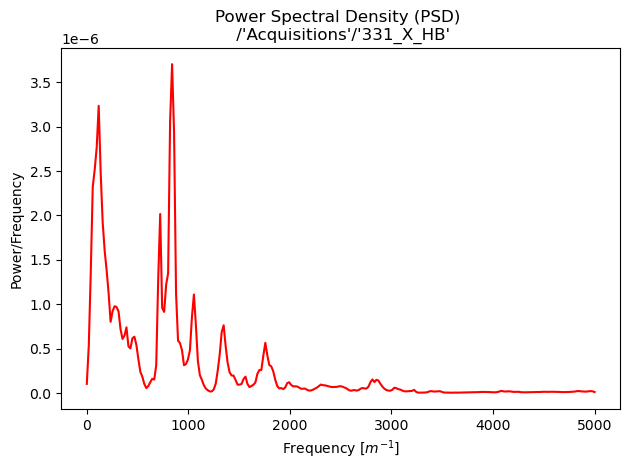

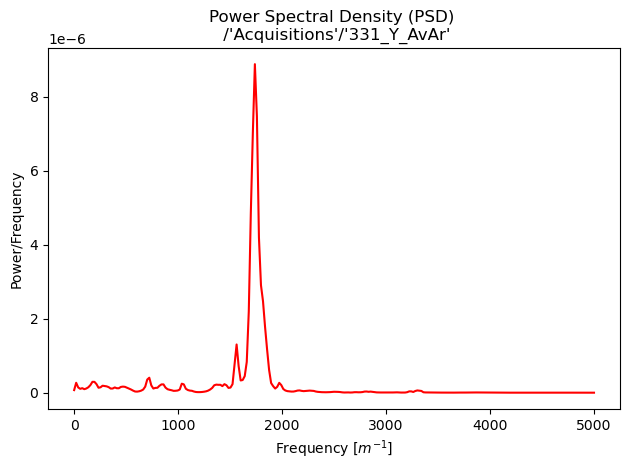

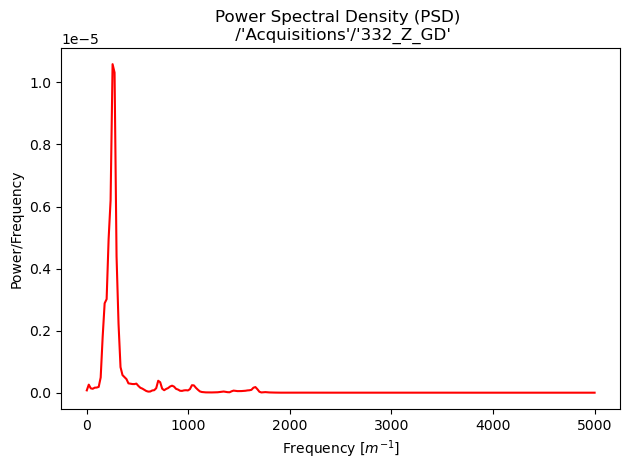

In [123]:
comp_psd(df, sensor="/'Acquisitions'/'331_X_HB'", nperseg=512, sampling_sensor="timestamp", plot=True)
comp_psd(df, sensor="/'Acquisitions'/'331_Y_AvAr'", nperseg=512, sampling_sensor="timestamp", plot=True)
comp_psd(df, sensor="/'Acquisitions'/'332_Z_GD'", nperseg=512, sampling_sensor="timestamp", plot=True)

<h1>On zoome sur le pic qui nous intéresse</h1>

In [133]:
def comp_psd_2(df1, sensor, nperseg=512, sampling_sensor="time", plot=False):

    df = df1.copy()
    #fs = int(1/np.abs(df[sampling_sensor].diff().mean()))
    if pd.api.types.is_datetime64_any_dtype(df1[sampling_sensor]):
      fs = int(1/np.abs(df[sampling_sensor].diff().dt.total_seconds().mean()))
    else:
      fs = int(1/np.abs(df[sampling_sensor].diff().mean()))  # Pour les cas où c'est déjà un float
    # Compute the PSD using the Welch method
    frequencies, psd = sn.welch(df[sensor].values, fs, nperseg=nperseg, average="mean")

    if plot :
        # Plot the PSD
        fig , axs = plt.subplots(1,1,sharex=True)
        # axs.semilogx(frequencies, psd)
        axs.plot(frequencies, psd, color="red")
        axs.set_title('Power Spectral Density (PSD) \n '+sensor)
        if sampling_sensor == "time":
            axs.set_xlabel('Frequency [$Hz$]')
        else :
            axs.set_xlabel('Frequency [$m^{-1}$]')

        axs.set_ylabel('Power/Frequency')

        plt.xlim(500,1000)
        
        fig.tight_layout()

    return frequencies, psd

(array([   0.     ,   19.53125,   39.0625 ,   58.59375,   78.125  ,
          97.65625,  117.1875 ,  136.71875,  156.25   ,  175.78125,
         195.3125 ,  214.84375,  234.375  ,  253.90625,  273.4375 ,
         292.96875,  312.5    ,  332.03125,  351.5625 ,  371.09375,
         390.625  ,  410.15625,  429.6875 ,  449.21875,  468.75   ,
         488.28125,  507.8125 ,  527.34375,  546.875  ,  566.40625,
         585.9375 ,  605.46875,  625.     ,  644.53125,  664.0625 ,
         683.59375,  703.125  ,  722.65625,  742.1875 ,  761.71875,
         781.25   ,  800.78125,  820.3125 ,  839.84375,  859.375  ,
         878.90625,  898.4375 ,  917.96875,  937.5    ,  957.03125,
         976.5625 ,  996.09375, 1015.625  , 1035.15625, 1054.6875 ,
        1074.21875, 1093.75   , 1113.28125, 1132.8125 , 1152.34375,
        1171.875  , 1191.40625, 1210.9375 , 1230.46875, 1250.     ,
        1269.53125, 1289.0625 , 1308.59375, 1328.125  , 1347.65625,
        1367.1875 , 1386.71875, 1406.25   , 1425

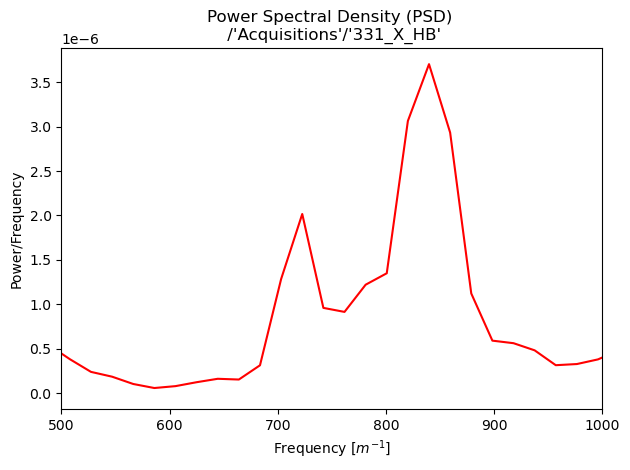

In [135]:
comp_psd_2(df, sensor="/'Acquisitions'/'331_X_HB'", nperseg=512, sampling_sensor="timestamp", plot=True)

<h1>On filtre le signal sur le pic à étudier</h1>

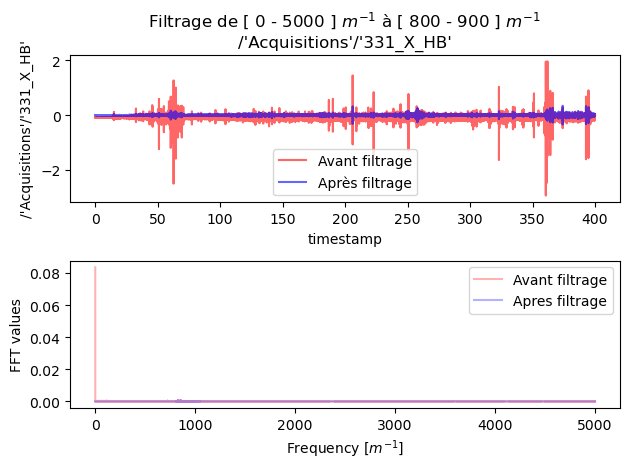

In [57]:
filt = band_pass_filter(df, ["/'Acquisitions'/'331_X_HB'"], fmin=800, fmax=900, order=2, sampling_sensor="timestamp", plot=True)

<h1>SAWP du signal filtré</h1>

0.0001
[12.5        12.47539034 12.4508774  12.42646059 12.40213937 12.37791316
 12.35378142 12.32974358 12.30579911 12.28194746 12.25818809 12.23452046
 12.21094406 12.18745834 12.1640628  12.1407569  12.11754014 12.094412
 12.07137199 12.04841959 12.0255543  12.00277564 11.98008311 11.95747623
 11.9349545  11.91251745 11.8901646  11.86789549 11.84570963 11.82360657
 11.80158584 11.77964698 11.75778954 11.73601306 11.71431709 11.6927012
 11.67116493 11.64970785 11.62832952 11.60702951 11.58580739 11.56466273
 11.54359511 11.52260411 11.50168931 11.4808503  11.46008667 11.439398
 11.4187839  11.39824396 11.37777778 11.35738496 11.33706512 11.31681785
 11.29664278 11.27653951 11.25650767 11.23654687 11.21665674 11.19683689
 11.17708697 11.1574066  11.13779541 11.11825304 11.09877913]


array([6.78481157e-09, 7.83270264e-09, 8.89939004e-09, ...,
       4.96852053e-06, 4.04168747e-06, 3.26915200e-06])

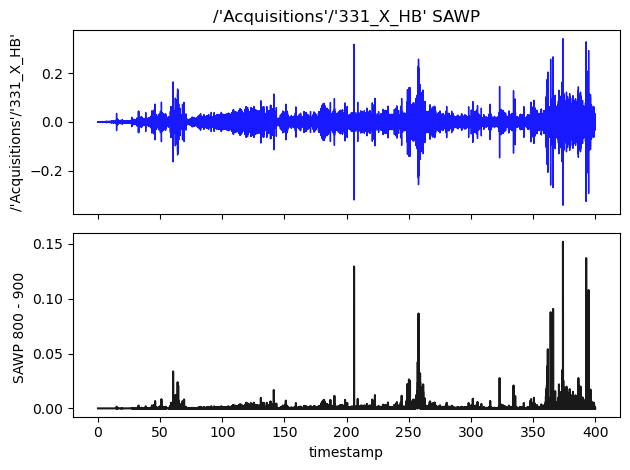

In [147]:
sawp(filt, sensor="/'Acquisitions'/'331_X_HB'", wavelet="cmor1.5-1.0", fmin=800, fmax=900, sampling_sensor="timestamp", plot=True)

<h1>On modifie la fonction SAWP pour donner en sortie les valeurs d'odométrie où l'amplitude de la SAWP en cette position est supérieure à un seuil</h1>

In [157]:
def sawp_2(df, sensor="Cab1_BE_AV_G", wavelet="cmor1.5-1.0", fmin=5, fmax=800, sampling_sensor="timestamp", plot=False, threshold=1):
    """
    Calcul la SAWP d'un signal 1D et retourne les valeurs ODO_Counter où l'amplitude est supérieure à un seuil.
    """

    # Suppression de la tendance linéaire
    p = np.polyfit(df[sampling_sensor], df[sensor], 1)
    dat_notrend = df[sensor] - np.polyval(p, df[sampling_sensor])

    # Normalisation
    std = dat_notrend.std()
    var = std**2
    dat_norm = dat_notrend / std  

    # Paramètres de l'ondelette
    dt = df[sampling_sensor].diff().mean()
    frequencies = np.array(np.linspace(fmin, fmax + 1, 65)) * dt  
    scales = pywt.frequency2scale(wavelet, frequencies)

    # Calcul de la Transformée en Ondelettes
    wave, freqs = pywt.cwt(np.array(dat_norm), scales, wavelet, sampling_period=dt)
    power = (np.abs(wave)) ** 2
    power /= scales[:, None]

    # Moyenne sur les échelles
    n = df[sensor].size
    c_delta = 1
    scale_avg = (scales * np.ones((n, 1))).transpose()
    scale_avg = power / scale_avg  
    scale_avg = var / c_delta * scale_avg[:, :].sum(axis=0)

    # Affichage si demandé
    if plot:
        fig, axs = plt.subplots(2, 1, sharex=True)
        axs[0].plot(df[sampling_sensor], df[sensor], "b-", linewidth=1, alpha=0.9)
        axs[1].plot(df[sampling_sensor], scale_avg, "k-", linewidth=1.5, alpha=0.9)
        axs[0].set_title(sensor + " SAWP")
        axs[1].set_xlabel(sampling_sensor)
        axs[0].set_ylabel(sensor)
        axs[1].set_ylabel(f"SAWP {fmin} - {fmax} ")

        fig.tight_layout()

    # Trouver les indices où l'amplitude dépasse le seuil
    indices_above_threshold = np.where(scale_avg > threshold)[0]

    # Récupérer les valeurs de ODO_Counter associées
    odo_above_threshold = df["/'Acquisitions'/'ODO_Counter'"].iloc[indices_above_threshold].tolist()

    return scale_avg, odo_above_threshold


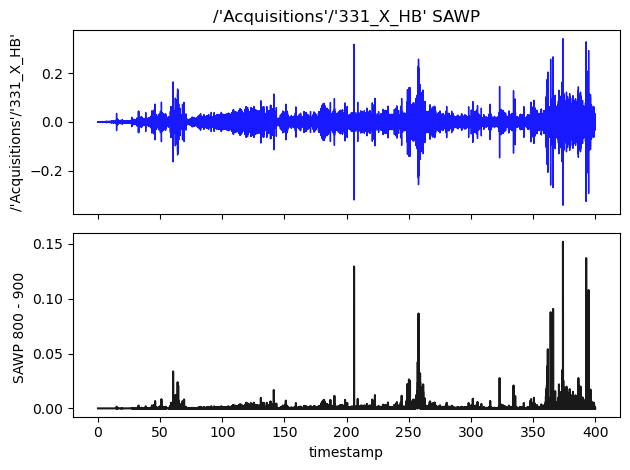

In [159]:
# Exécution de la fonction
scale_avg, odo_above_threshold = sawp_2(filt, sensor="/'Acquisitions'/'331_X_HB'", wavelet="cmor1.5-1.0", fmin=800, fmax=900, sampling_sensor="timestamp", plot=True, threshold=0.07)

In [161]:
# Affichage des odométries où l'amplitude est supérieure au seuil
print(odo_above_threshold)

[33386538.0, 33386540.0, 33386542.0, 33386544.0, 33386546.0, 33386548.0, 33386550.0, 33386552.0, 33386555.0, 33386557.0, 33386559.0, 33386561.0, 33386563.0, 33386566.0, 33386568.0, 33386570.0, 33386572.0, 33386574.0, 33386576.0, 33386578.0, 33386580.0, 33386582.0, 33386584.0, 33386586.0, 33386588.0, 33386590.0, 33386592.0, 33386594.0, 33386596.0, 33386598.0, 33386600.0, 33386602.0, 33386605.0, 33386607.0, 33386609.0, 33386611.0, 33386613.0, 33386615.0, 33386617.0, 33386619.0, 33386621.0, 33386623.0, 33386625.0, 33386627.0, 33386629.0, 33386631.0, 33386633.0, 33386635.0, 33386637.0, 33386639.0, 33386642.0, 33386644.0, 33386646.0, 33386648.0, 33386650.0, 33386653.0, 33386655.0, 33386657.0, 33386659.0, 33386661.0, 33386663.0, 33386665.0, 33386667.0, 33386669.0, 33386671.0, 33386673.0, 33386675.0, 33386677.0, 33386679.0, 33386681.0, 33386683.0, 33386685.0, 33386688.0, 33386690.0, 33386692.0, 33386694.0, 33386696.0, 33386699.0, 33386701.0, 33386703.0, 34489291.0, 34489293.0, 34489295.0, 344

<h1>Transformée de Hilbert</h1>

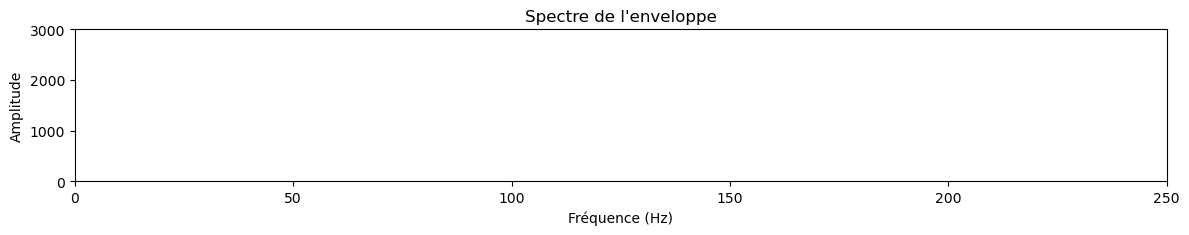

In [75]:
from scipy.signal import hilbert
fe = 10000

analytic_signal = hilbert(filt)
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 3000)
plt.xlim(0, 250)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()

In [71]:
df.columns

Index(['/'Acquisitions'/'331_X_HB'', '/'Acquisitions'/'331_Z_GD'',
       '/'Acquisitions'/'331_Y_AvAr'', '/'Acquisitions'/'332_X_HB'',
       '/'Acquisitions'/'332_Z_GD'', '/'Acquisitions'/'332_Y_AvAr'',
       '/'Acquisitions'/'Audio_1'', '/'Acquisitions'/'Audio_2'',
       '/'Acquisitions'/'ODO_Counter'', 'timestamp'],
      dtype='object')

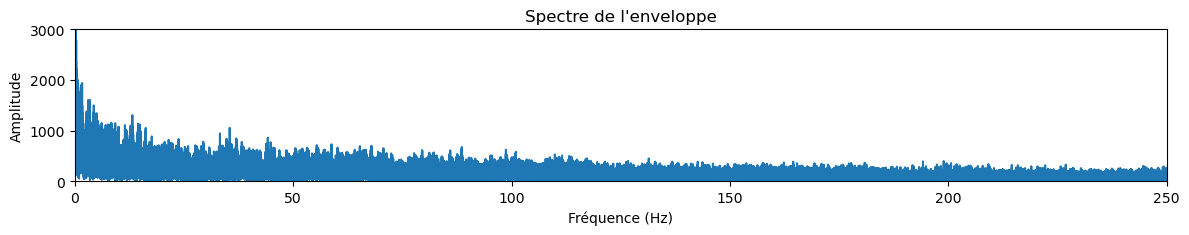

In [73]:
analytic_signal = hilbert(df["/'Acquisitions'/'331_X_HB'"])
envelope = np.abs(analytic_signal)

fft_envelope = np.fft.fft(envelope)
freqs = np.fft.fftfreq(len(envelope), 1/fe)

plt.figure(figsize=(12, 6))

# Spectre de l'enveloppe
plt.subplot(3, 1, 3)
plt.plot(freqs[:len(freqs)//2], np.abs(fft_envelope[:len(freqs)//2]))
plt.title('Spectre de l\'enveloppe')
plt.xlabel('Fréquence (Hz)')
plt.ylabel('Amplitude')
plt.ylim(0, 3000)
plt.xlim(0, 250)  # Zoom sur les basses fréquences
plt.tight_layout()
plt.show()